## Analise Exploratória do DataSet DataSUS - SRAG
By Iasmin Maeques

Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc

In [1]:
# Instalação de bibliotecas
!pip install pandas scikit-learn seaborn matplotlib --quiet

In [2]:
# Importações principais
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
import numpy as np
sns.set(style='whitegrid')

In [3]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [4]:
# definindo colunas obrigatorias e algumas essenciais
colunas_obrigatorias = [
    "DT_NOTIFIC", "DT_SIN_PRI", "SG_UF_NOT","ID_MUNICIP", "CO_MUN_NOT", "ID_UNIDADE", "CO_UNI_NOT","TEM_CPF", "NU_CPF", "ESTRANG", "NU_CNS","NM_PACIENT", "CS_SEXO", "NU_IDADE_N", "TP_IDADE",
    "CS_GESTANT", "CS_RACA", "POV_CT", "TP_POV_CT","SG_UF", "ID_MN_RESI", "CO_MUN_RES","ID_PAIS", "CO_PAIS", "VACINA_COV",
    "DT_INTERNA", "CLASSI_FIN", "CLASSI_OUT", "DT_ENCERRA","EVOLUCAO", "DT_NASC", "FATOR_RISC", "DT_RES", "DT_EVOLUCA", "NU_DO"
]

In [5]:
# Verifica quais colunas da lista existem no DataFrame
colunas_presentes = [col for col in colunas_obrigatorias if col in df.columns]

# Filtra apenas essas colunas
df_obrigatorio = df[colunas_presentes]

# Visualiza o novo DataFrame (5 pimeiros)
df_obrigatorio.head()

,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,CO_UNI_NOT,ESTRANG,CS_SEXO,NU_IDADE_N,...,VACINA_COV,DT_INTERNA,CLASSI_FIN,CLASSI_OUT,DT_ENCERRA,EVOLUCAO,DT_NASC,FATOR_RISC,DT_RES,DT_EVOLUCA
0,04/01/2024,04/01/2024,CE,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,2526638,2.0,F,4,...,2.0,NaN,4.0,NaN,12/01/2024,1.0,15/08/2019,1,NaN,12/01/2024
1,15/01/2024,31/12/2023,BA,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,3814378,2.0,M,79,...,1.0,12/01/2024,5.0,NaN,01/02/2024,1.0,26/07/1944,1,NaN,18/01/2024
2,15/01/2024,10/01/2024,PB,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,2593262,2.0,M,59,...,2.0,10/01/2024,5.0,NaN,24/01/2024,3.0,24/07/1964,1,NaN,24/01/2024
3,11/01/2024,04/01/2024,GO,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,7532024,2.0,M,72,...,1.0,NaN,4.0,NaN,16/01/2024,2.0,21/10/1951,1,NaN,14/01/2024
4,16/01/2024,14/01/2024,BA,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,7033753,2.0,F,84,...,2.0,16/01/2024,4.0,NaN,25/01/2024,9.0,19/09/1939,1,NaN,NaN


In [9]:
#campos que estao faltando no df
colunas_faltando = [col for col in colunas_obrigatorias if col not in df.columns]
print("Colunas ausentes no DataFrame:", colunas_faltando)

Colunas ausentes no DataFrame: ['TEM_CPF', 'NU_CPF', 'NU_CNS', 'NM_PACIENT', 'POV_CT', 'TP_POV_CT', 'NU_DO']


In [10]:
df_obrigatorio.to_csv("df_srag_obito_limpo.csv", index=False)
df_obrigatorio

,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,CO_UNI_NOT,ESTRANG,CS_SEXO,NU_IDADE_N,...,VACINA_COV,DT_INTERNA,CLASSI_FIN,CLASSI_OUT,DT_ENCERRA,EVOLUCAO,DT_NASC,FATOR_RISC,DT_RES,DT_EVOLUCA
0,04/01/2024,04/01/2024,CE,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,2526638,2.0,F,4,...,2.0,NaN,4.0,NaN,12/01/2024,1.0,15/08/2019,1,NaN,12/01/2024
1,15/01/2024,31/12/2023,BA,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,3814378,2.0,M,79,...,1.0,12/01/2024,5.0,NaN,01/02/2024,1.0,26/07/1944,1,NaN,18/01/2024
2,15/01/2024,10/01/2024,PB,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,2593262,2.0,M,59,...,2.0,10/01/2024,5.0,NaN,24/01/2024,3.0,24/07/1964,1,NaN,24/01/2024
3,11/01/2024,04/01/2024,GO,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,7532024,2.0,M,72,...,1.0,NaN,4.0,NaN,16/01/2024,2.0,21/10/1951,1,NaN,14/01/2024
4,16/01/2024,14/01/2024,BA,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,7033753,2.0,F,84,...,2.0,16/01/2024,4.0,NaN,25/01/2024,9.0,19/09/1939,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,23/11/2024,MG,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,26948,2.0,F,11,...,1.0,26/11/2024,4.0,NaN,20/12/2024,1.0,07/09/2013,1,NaN,05/12/2024
266426,06/12/2024,04/12/2024,MG,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,2222043,2.0,M,3,...,2.0,06/12/2024,2.0,NaN,27/01/2025,1.0,09/09/2024,2,NaN,21/12/2024
266427,16/12/2024,13/12/2024,SP,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,2802511,2.0,M,3,...,2.0,NaN,NaN,NaN,NaN,NaN,15/08/2021,1,NaN,NaN
266428,05/12/2024,04/12/2024,DF,BRASILIA,530010,HOSPITAL AGUAS CLARAS,49867,2.0,F,2,...,2.0,05/12/2024,2.0,NaN,05/12/2024,1.0,22/08/2022,2,NaN,19/12/2024


## Grafico baseado nos registros de sexo da pessoa
Coluna CS_SEXO, onde:

'M': 'Masculino',

'F': 'Feminino',

'I': 'Ignorado'


<ipython-input-13-01967daea308>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette='pastel')


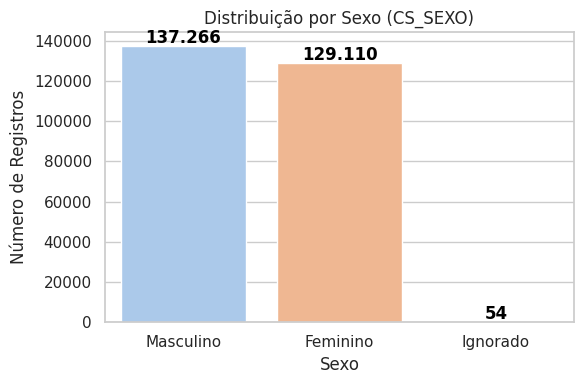

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear os valores para nomes legíveis
sexo_map = {
    'M': 'Masculino',
    'F': 'Feminino',
    'I': 'Ignorado'
}
df['CS_SEXO_LABEL'] = df['CS_SEXO'].map(sexo_map)

# Contar valores
sexo_counts = df['CS_SEXO_LABEL'].value_counts()

# Plotar gráfico
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=sexo_counts.index, y=sexo_counts.values, palette='pastel')

# Adicionar rótulos numéricos em cima de cada barra
for i, v in enumerate(sexo_counts.values):
    ax.text(i, v + max(sexo_counts.values) * 0.01, f"{v:,.0f}".replace(",", "."),
            color='black', ha='center', fontweight='bold')

plt.title('Distribuição por Sexo (CS_SEXO)')
plt.xlabel('Sexo')
plt.ylabel('Número de Registros')
plt.tight_layout()
plt.show()


## Gráfico baseado na UF da unidade de Notificação
SG_UF_NOT: unidade Federativa onde está localizada a Unidade que realizou a notificação

<ipython-input-14-950a2d9cfefc>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='crest')


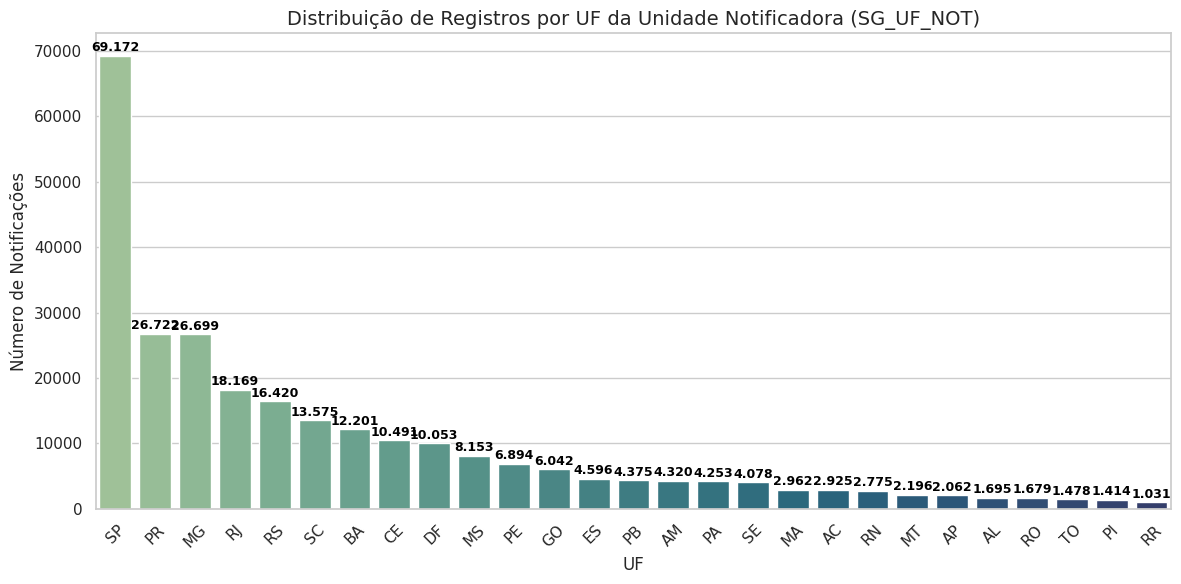

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de notificações por UF
uf_counts = df['SG_UF_NOT'].value_counts().sort_values(ascending=False)

# Plotar o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='crest')

# Adicionar rótulos numéricos nas barras
for i, v in enumerate(uf_counts.values):
    ax.text(i, v + max(uf_counts.values) * 0.01, f"{v:,.0f}".replace(",", "."),
            color='black', ha='center', fontweight='bold', fontsize=9)

plt.title('Distribuição de Registros por UF da Unidade Notificadora (SG_UF_NOT)', fontsize=14)
plt.xlabel('UF')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Grafico baseado na Idade do Paciente
Distribuição de Idade Informada/Aparente (NU_IDADE_N).
O campo NU_IDADE_N: Idade informada pelo paciente quando não se sabe a data de nascimento.

Na falta desse dado é registrada a idade aparente.
Obs.: limitado por 0 a 120 anos;

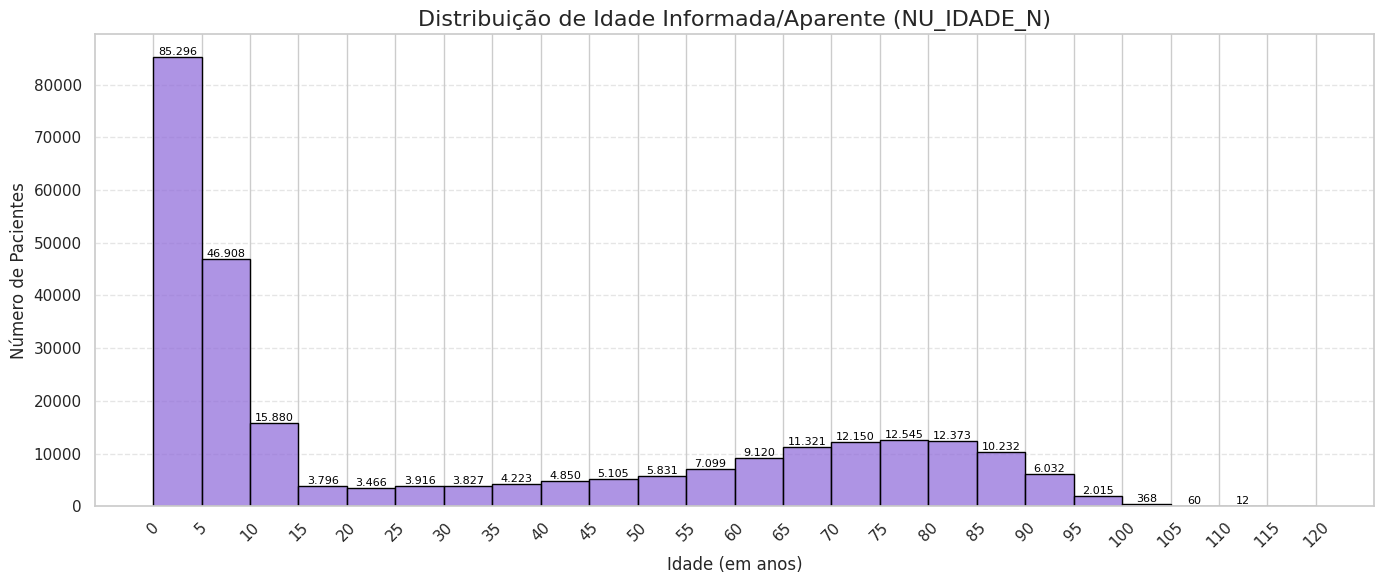

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar idades válidas
df_idade = df[df['NU_IDADE_N'].notnull()]
df_idade = df_idade[df_idade['NU_IDADE_N'] >= 0]
df_idade = df_idade[df_idade['NU_IDADE_N'] <= 120]  # limitar idade a 0–120 anos

# Bins por faixa de 5 anos
bins = np.arange(0, 125, 5)

# Plot
plt.figure(figsize=(14, 6))
ax = sns.histplot(df_idade['NU_IDADE_N'], bins=bins, color='mediumpurple', edgecolor='black')

# Rótulos nas barras (opcional)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}'.replace(',', '.'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, color='black')

# Ajustes visuais
plt.title('Distribuição de Idade Informada/Aparente (NU_IDADE_N)', fontsize=16)
plt.xlabel('Idade (em anos)', fontsize=12)
plt.ylabel('Número de Pacientes', fontsize=12)
plt.xticks(bins, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


CS_GESTANT: Idade gestacional da paciente.
Sendo que:
1-1º Trimestre
2-2º Trimestre
3-3º Trimestre
4-Idade Gestacional
Ignorada
5-Não
6-Não se aplica
9-Ignorado


<ipython-input-19-5cf89c642c12>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


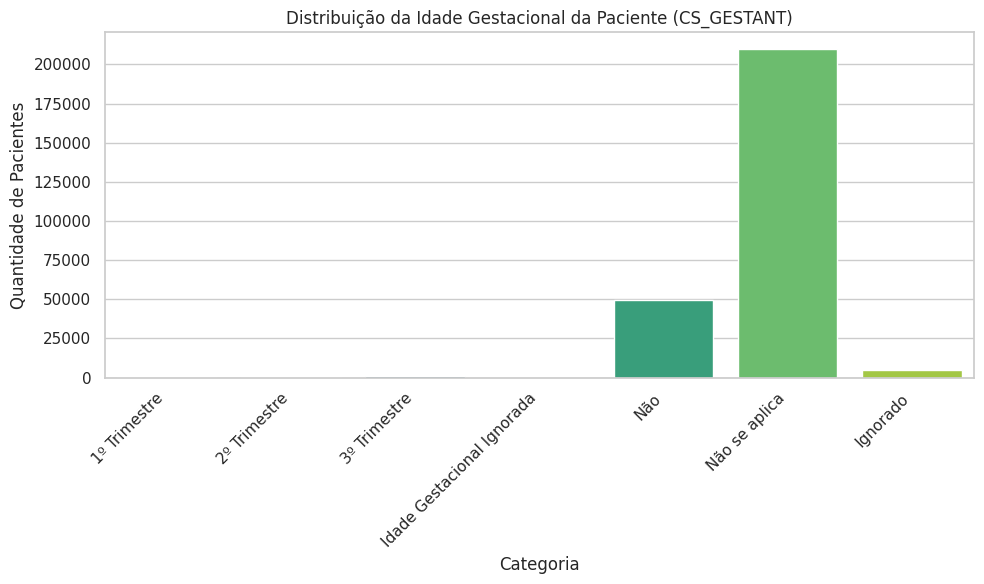

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplo de dados simulados (você deve substituir pelo seu df real)
# df = pd.read_csv('seu_arquivo.csv')

# Mapear os códigos para as descrições
gestational_age_map = {
    1: '1º Trimestre',
    2: '2º Trimestre',
    3: '3º Trimestre',
    4: 'Idade Gestacional Ignorada',
    5: 'Não',
    6: 'Não se aplica',
    9: 'Ignorado'
}

# Substituir valores na coluna para as descrições
df['CS_GESTANT_DESC'] = df['CS_GESTANT'].map(gestational_age_map)

# Contar frequências
counts = df['CS_GESTANT_DESC'].value_counts().reindex(gestational_age_map.values())

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.title('Distribuição da Idade Gestacional da Paciente (CS_GESTANT)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

CS_RACA: Cor ou raça declarada pelo paciente:
Branca; Preta; Amarela; Parda (pessoa que se declarou mulata, cabocla, cafuza, mameluca ou mestiça de preto com pessoa de outra cor ou raça); e, Indígena.

Onde:
1-Branca
2-Preta
3-Amarela
4-Parda
5-Indígena
9-Ignorado

<ipython-input-22-03b1de160d0f>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette='Set2')


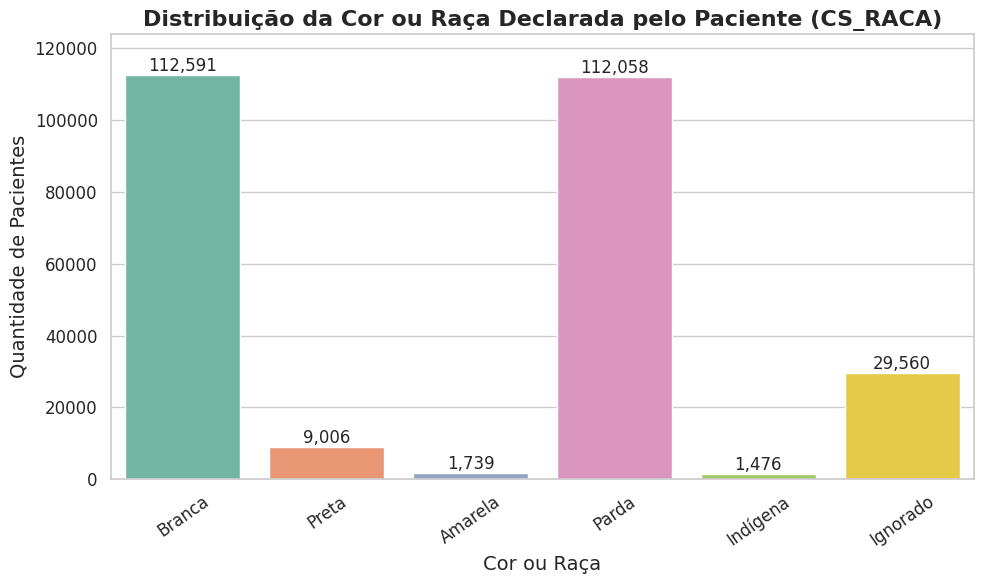

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear os códigos para categorias
raca_map = {
    1: 'Branca',
    2: 'Preta',
    3: 'Amarela',
    4: 'Parda',
    5: 'Indígena',
    9: 'Ignorado'
}

df['CS_RACA_DESC'] = df['CS_RACA'].map(raca_map)

order = ['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena', 'Ignorado']
counts = df['CS_RACA_DESC'].value_counts().reindex(order)

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

barplot = sns.barplot(x=counts.index, y=counts.values, palette='Set2')

# Adicionar valores acima das barras
for index, value in enumerate(counts.values):
    barplot.text(index, value + max(counts.values)*0.01, f'{value:,}', ha='center', fontsize=12)

plt.title('Distribuição da Cor ou Raça Declarada pelo Paciente (CS_RACA)', fontsize=16, weight='bold')
plt.xlabel('Cor ou Raça', fontsize=14)
plt.ylabel('Quantidade de Pacientes', fontsize=14)
plt.xticks(rotation=35, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, counts.max() * 1.1)  # espaço extra para os valores acima das barras

plt.tight_layout()
plt.show()


## Pais de residencia do paciente
ID_PAIS: País de residência do paciente.
Tabela com código e nome dos Países.

<ipython-input-25-1ccdcd498f5f>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')


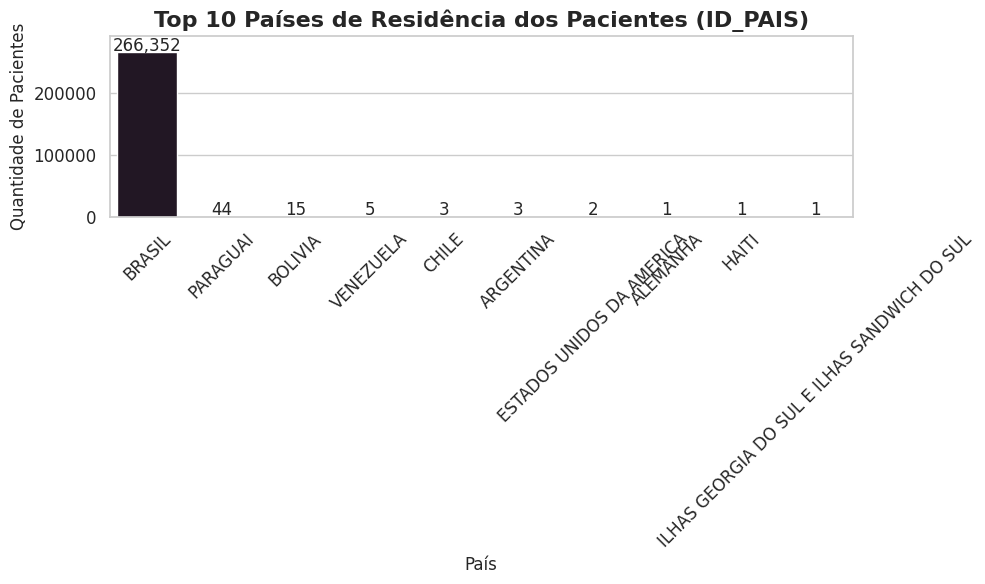

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponha que df tenha a coluna ID_PAIS com códigos numéricos dos países

# Se você tiver um dicionário para mapear código para país, por exemplo:
pais_map = {
    1058: 'Brasil',
    1065: 'Argentina',
    1077: 'Chile',
    1081: 'Colômbia',
    # ... adicione mais conforme seu dicionário
}

# Mapear códigos para nomes (se tiver)
if 'ID_PAIS' in df.columns:
    df['PAIS'] = df['ID_PAIS'].map(pais_map)
else:
    print("Coluna ID_PAIS não encontrada no DataFrame.")

# Se não tem o mapeamento, pode usar os códigos mesmo:
df['PAIS'] = df['PAIS'].fillna(df['ID_PAIS'].astype(str))

# Contar os 10 países mais frequentes
top_paises = df['PAIS'].value_counts().head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
barplot = sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')

# Adicionar valores acima das barras
for index, value in enumerate(top_paises.values):
    barplot.text(index, value + max(top_paises.values)*0.01, f'{value:,}', ha='center', fontsize=12)

plt.title('Top 10 Países de Residência dos Pacientes (ID_PAIS)', fontsize=16, weight='bold')
plt.xlabel('País')
plt.ylabel('Quantidade de Pacientes')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, top_paises.max() * 1.1)
plt.tight_layout()
plt.show()


VACINA_COV: informar se o paciente recebeu vacina COVID-19, após verificar a documentação / caderneta.

Onde:
1-Sim
2-Não
9-Ignorado

<ipython-input-26-86cc577284b2>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=palette)


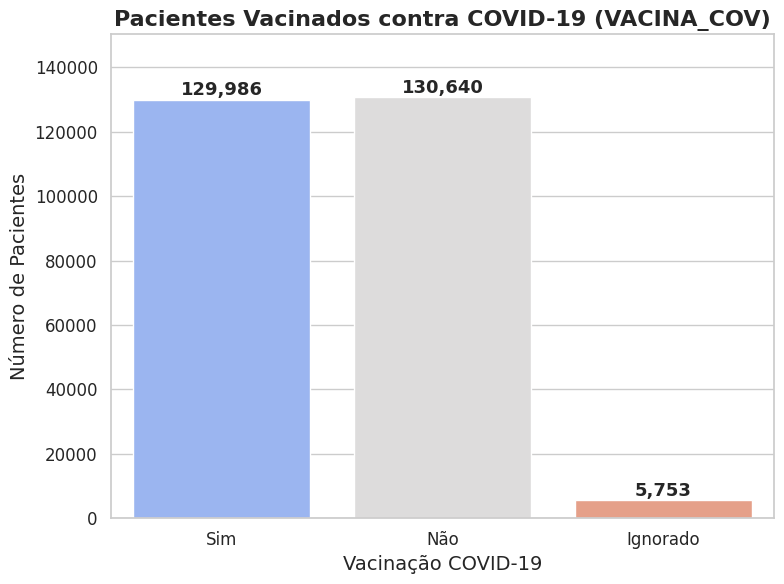

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos
vacina_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

# Mapear os valores
df['VACINA_COV_DESC'] = df['VACINA_COV'].map(vacina_map)

# Contar frequências na ordem correta
order = ['Sim', 'Não', 'Ignorado']
counts = df['VACINA_COV_DESC'].value_counts().reindex(order)

# Configurações de estilo
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")

# Cores suaves
palette = sns.color_palette("coolwarm", len(counts))
barplot = sns.barplot(x=counts.index, y=counts.values, palette=palette)

# Mostrar valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=13, weight='bold')

# Título e labels
plt.title('Pacientes Vacinados contra COVID-19 (VACINA_COV)', fontsize=16, weight='bold')
plt.xlabel('Vacinação COVID-19', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()


# Classificação Final
CLASSI_FIN: Diagnóstico final do caso.
Se tiver resultados divergentes entre as metodologias laboratoriais, priorizar  
resultado  do  RT-PCR.

| Código | Descrição                         |
| ------ | --------------------------------- |
| 1      | SRAG por Influenza                |
| 2      | SRAG por outro vírus respiratório |
| 3      | SRAG por outro agente etiológico  |
| 4      | SRAG não especificado             |
| 5      | SRAG por COVID-19                 |


<ipython-input-27-ecb1e5ac7379>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


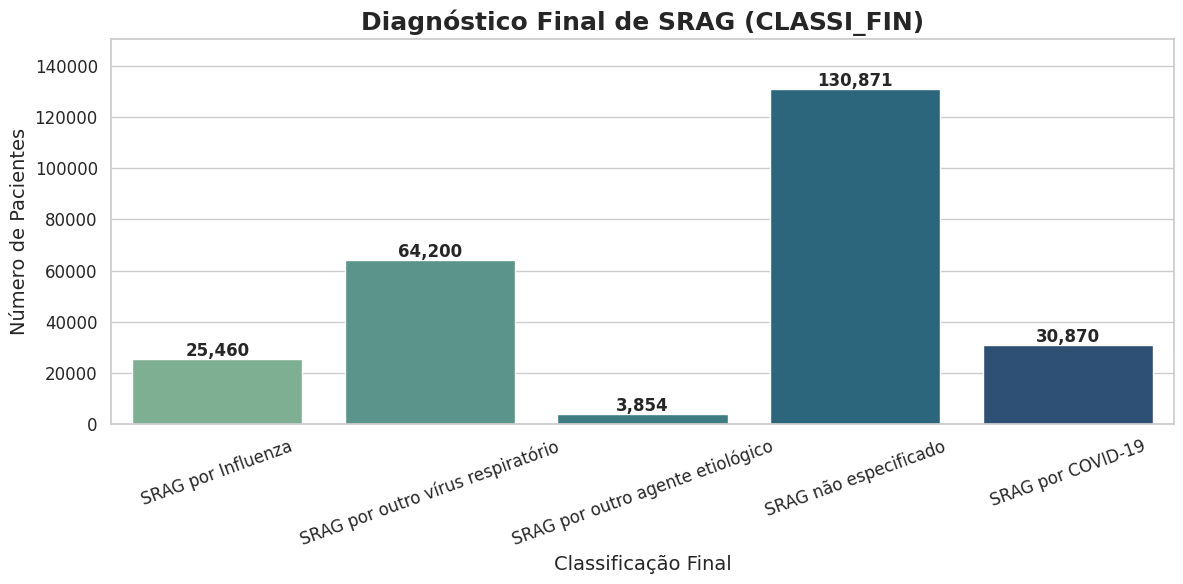

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos
classi_fin_map = {
    1: 'SRAG por Influenza',
    2: 'SRAG por outro vírus respiratório',
    3: 'SRAG por outro agente etiológico',
    4: 'SRAG não especificado',
    5: 'SRAG por COVID-19'
}

# Mapear os valores
df['CLASSI_FIN_DESC'] = df['CLASSI_FIN'].map(classi_fin_map)

# Contar as frequências e garantir ordem lógica
order = [
    'SRAG por Influenza',
    'SRAG por outro vírus respiratório',
    'SRAG por outro agente etiológico',
    'SRAG não especificado',
    'SRAG por COVID-19'
]
counts = df['CLASSI_FIN_DESC'].value_counts().reindex(order)

# Plot com estilo bonito
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")
colors = sns.color_palette("crest", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adicionar valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Títulos e rótulos
plt.title('Diagnóstico Final de SRAG (CLASSI_FIN)', fontsize=18, weight='bold')
plt.xlabel('Classificação Final', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)
plt.xticks(rotation=20, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


CLASSI_OUT: Descrição de qual outro agente etiológico foi identificado

<ipython-input-28-a63ff4eb6d58>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=top_classi_out.values, y=top_classi_out.index, palette=colors)


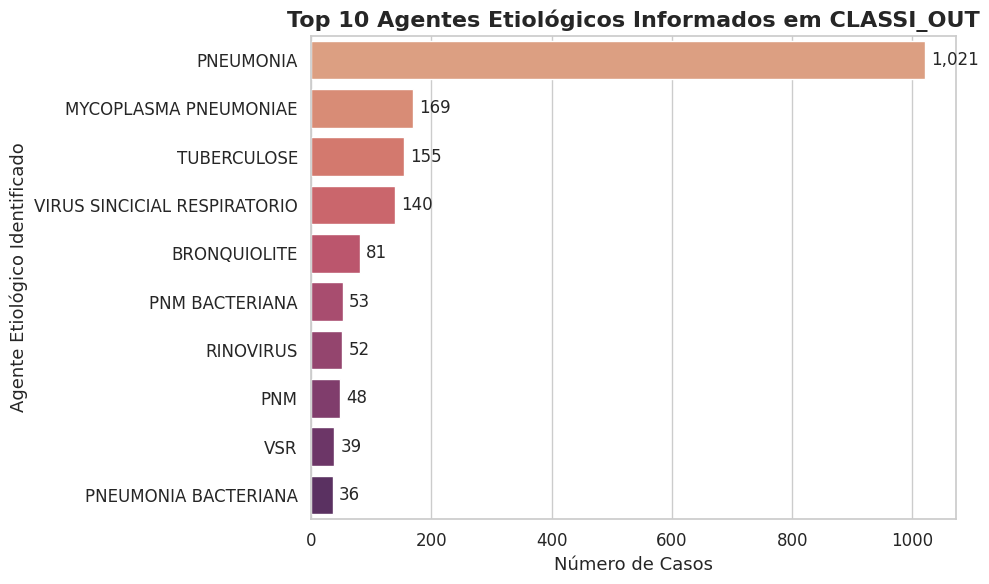

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Remover valores nulos ou em branco
df_outros = df['CLASSI_OUT'].dropna()
df_outros = df_outros[df_outros.str.strip() != '']

# Contar os 10 mais frequentes
top_classi_out = df_outros.value_counts().head(10)

# Plotar gráfico de barras horizontais
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
colors = sns.color_palette("flare", len(top_classi_out))

barplot = sns.barplot(x=top_classi_out.values, y=top_classi_out.index, palette=colors)

# Adicionar valores ao lado das barras
for i, v in enumerate(top_classi_out.values):
    barplot.text(v + max(top_classi_out.values)*0.01, i, f'{v:,}', va='center', fontsize=12)

plt.title('Top 10 Agentes Etiológicos Informados em CLASSI_OUT', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Agente Etiológico Identificado', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


## word cloud Agentes Etiológicos Informados em CLASSI_OUT

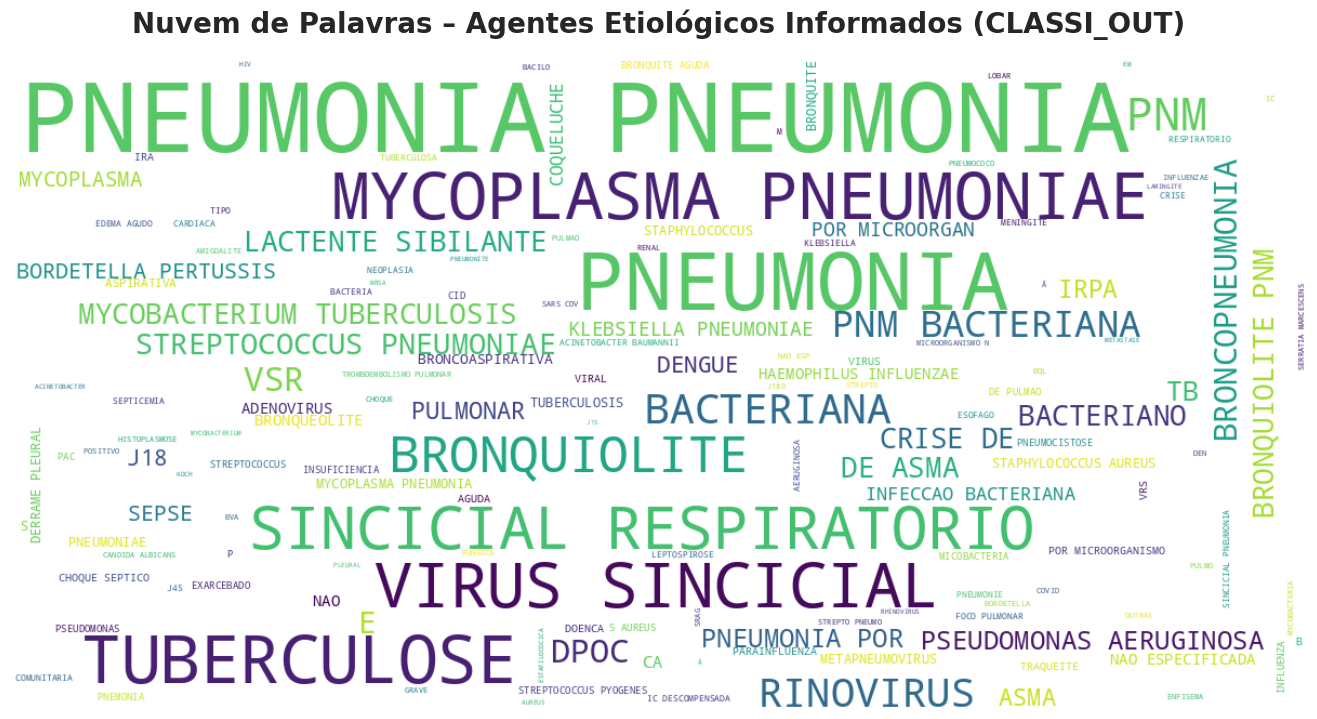

In [30]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Filtrar apenas CLASSI_FIN == 3 e textos válidos
df_outros = df[df['CLASSI_FIN'] == 3]['CLASSI_OUT'].dropna()
df_outros = df_outros[df_outros.str.strip() != '']

# Concatenar todos os agentes em uma string
texto = ' '.join(df_outros.astype(str).tolist())

# Stopwords personalizadas para remover termos irrelevantes (adicione mais se quiser)
stopwords = set(STOPWORDS)
stopwords.update([
    'não', 'informado', 'outro', 'outros', 'agente', 'etiológico',
    'identificado', 'qual', 'causador', 'causada', 'causado'
])

# Criar a word cloud com estilo aprimorado
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=stopwords,
    colormap='viridis',  # alternativa: 'plasma', 'magma', 'inferno'
    max_words=150,
    max_font_size=90,
    contour_color='steelblue',
    contour_width=2,
    random_state=42
).generate(texto)

# Exibir
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Agentes Etiológicos Informados (CLASSI_OUT)', fontsize=20, weight='bold', pad=20)
plt.tight_layout(pad=0)
plt.show()


EVOLUCAO: Evolução do caso; Onde:

| Código | Descrição               |
| ------ | ----------------------- |
| 1      | Cura                    |
| 2      | Óbito                   |
| 3      | Óbito por outras causas |
| 9      | Ignorado                |


<ipython-input-31-72234d7c4652>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


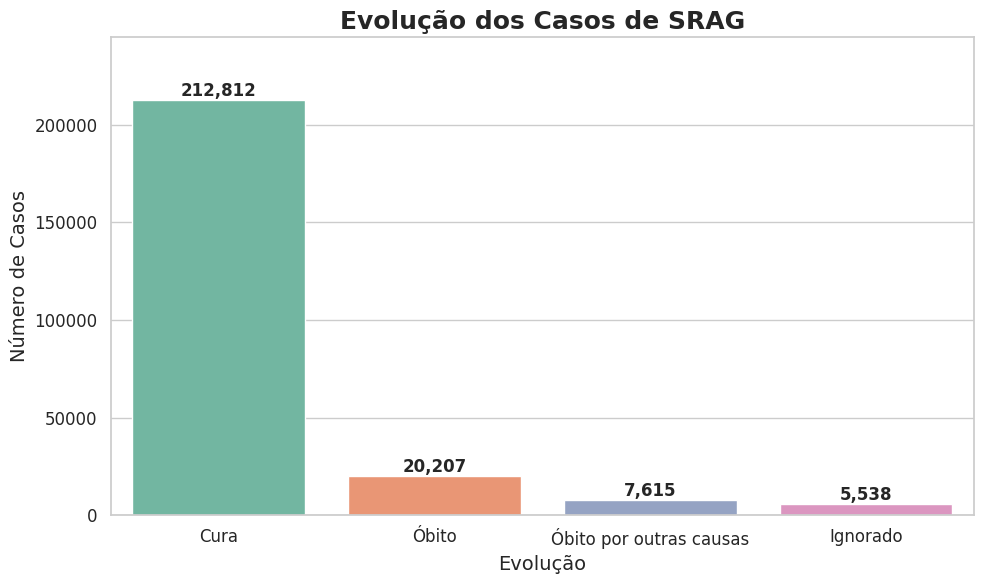

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos valores
evolucao_map = {
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito por outras causas',
    9: 'Ignorado'
}

# Mapear os valores
df['EVOLUCAO_DESC'] = df['EVOLUCAO'].map(evolucao_map)

# Contagem com ordenação personalizada
order = ['Cura', 'Óbito', 'Óbito por outras causas', 'Ignorado']
counts = df['EVOLUCAO_DESC'].value_counts().reindex(order)

# Estilo e cores
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
colors = sns.color_palette("Set2", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adiciona os valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Títulos e rótulos
plt.title('Evolução dos Casos de SRAG', fontsize=18, weight='bold')
plt.xlabel('Evolução', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


FATOR_RISC: Paciente apresenta algum fator de risco.
Onde:

| Código | Descrição |
| ------ | --------- |
| 1      | Sim       |
| 2      | Não       |
| 9      | Ignorado  |


<ipython-input-32-56f637c7ed00>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)


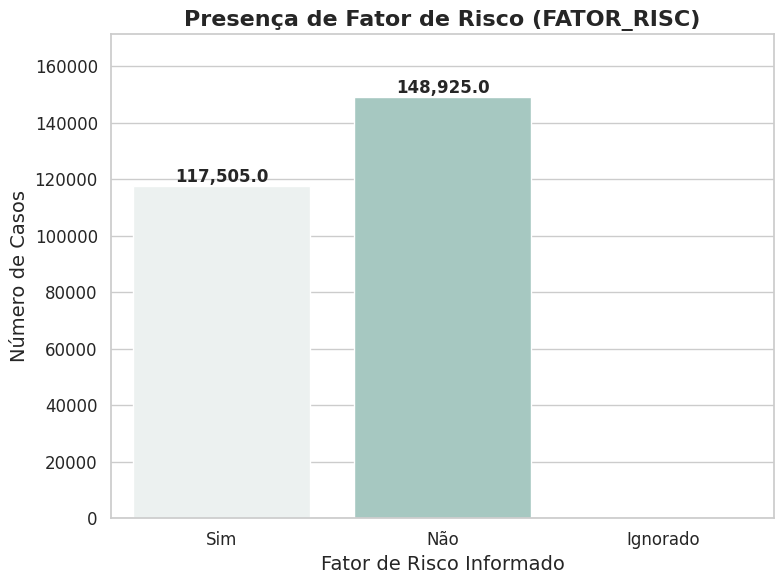

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamento dos códigos para texto
fator_risco_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

# Aplicar mapeamento
df['FATOR_RISC_DESC'] = df['FATOR_RISC'].map(fator_risco_map)

# Contagem dos valores com ordem personalizada
order = ['Sim', 'Não', 'Ignorado']
counts = df['FATOR_RISC_DESC'].value_counts().reindex(order)

# Plot com estilo moderno
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")
colors = sns.color_palette("light:#5A9", len(order))

barplot = sns.barplot(x=counts.index, y=counts.values, palette=colors)

# Adiciona os valores acima das barras
for i, v in enumerate(counts.values):
    barplot.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center', fontsize=12, weight='bold')

# Título e rótulos
plt.title('Presença de Fator de Risco (FATOR_RISC)', fontsize=16, weight='bold')
plt.xlabel('Fator de Risco Informado', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


# Análise cruzada com evolução (EVOLUCAO) para ver a relação entre fator de risco e óbito

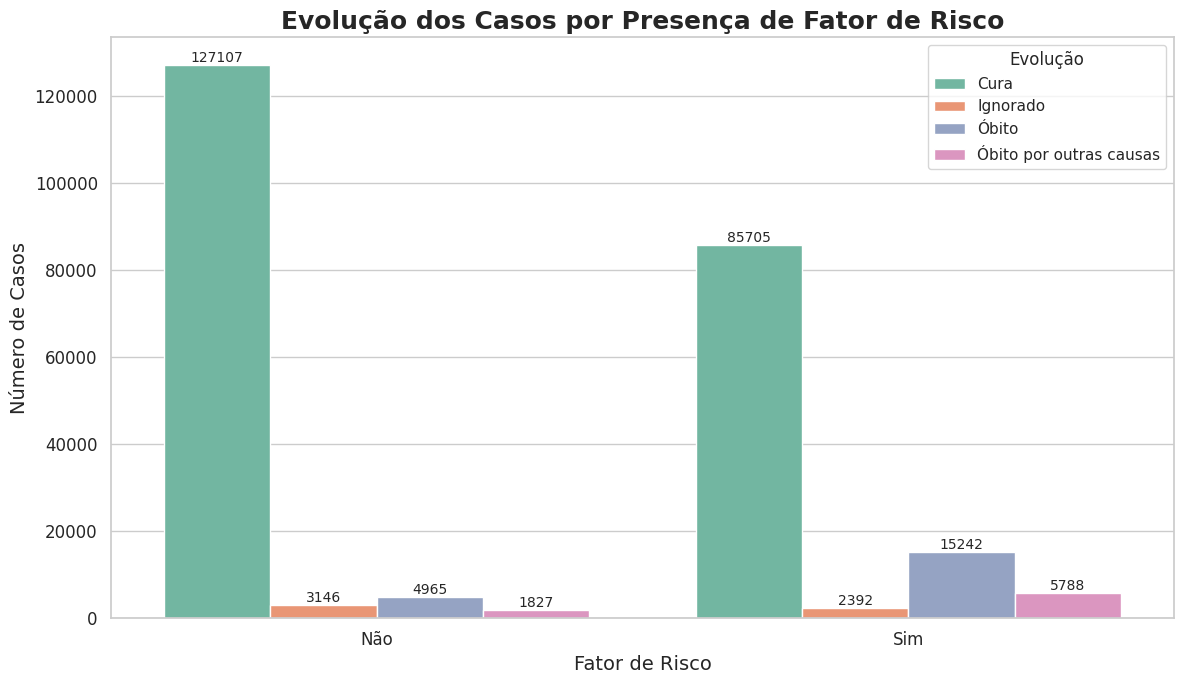

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamentos
fator_risco_map = {
    1: 'Sim',
    2: 'Não',
    9: 'Ignorado'
}

evolucao_map = {
    1: 'Cura',
    2: 'Óbito',
    3: 'Óbito por outras causas',
    9: 'Ignorado'
}

# Aplicar mapeamentos
df['FATOR_RISC_DESC'] = df['FATOR_RISC'].map(fator_risco_map)
df['EVOLUCAO_DESC'] = df['EVOLUCAO'].map(evolucao_map)

# Contagem cruzada
df_plot = df.groupby(['FATOR_RISC_DESC', 'EVOLUCAO_DESC']).size().reset_index(name='Total')

# Gráfico de barras agrupadas
plt.figure(figsize=(12,7))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=df_plot,
    x='FATOR_RISC_DESC',
    y='Total',
    hue='EVOLUCAO_DESC',
    palette='Set2'
)

# Adiciona rótulos nos topos das barras
for container in barplot.containers:
    barplot.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Ajustes de layout
plt.title('Evolução dos Casos por Presença de Fator de Risco', fontsize=18, weight='bold')
plt.xlabel('Fator de Risco', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Evolução', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


# Gráfico de Sintomas Sim/Não (binários)

Selecionado os Sintomas (FEBRE,  TOSSE, GARGANTA, DISPNEIA , DESC_RESP, SATURACAO, DIARREIA, VOMITO, DOR_ABD , FADIGA, PERD_OLFT, PERD_PALA, OUTRO_SIN)

Onde:
1-Sim
2-Não
9-Ignorado


In [34]:
sintomas = [
    'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
    'DIARREIA', 'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'OUTRO_SIN'
]

# Rótulos amigáveis
labels = {
    'FEBRE': 'Febre',
    'TOSSE': 'Tosse',
    'GARGANTA': 'Dor de garganta',
    'DISPNEIA': 'Dispneia',
    'DESC_RESP': 'Desconforto respiratório',
    'SATURACAO': 'Sat. O2 < 95%',
    'DIARREIA': 'Diarreia',
    'VOMITO': 'Vômito',
    'DOR_ABD': 'Dor abdominal',
    'FADIGA': 'Fadiga',
    'PERD_OLFT': 'Perda olfato',
    'PERD_PALA': 'Perda paladar',
    'OUTRO_SIN': 'Outro sintoma (Sim/Não)'
}


<ipython-input-35-e07009c238b9>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


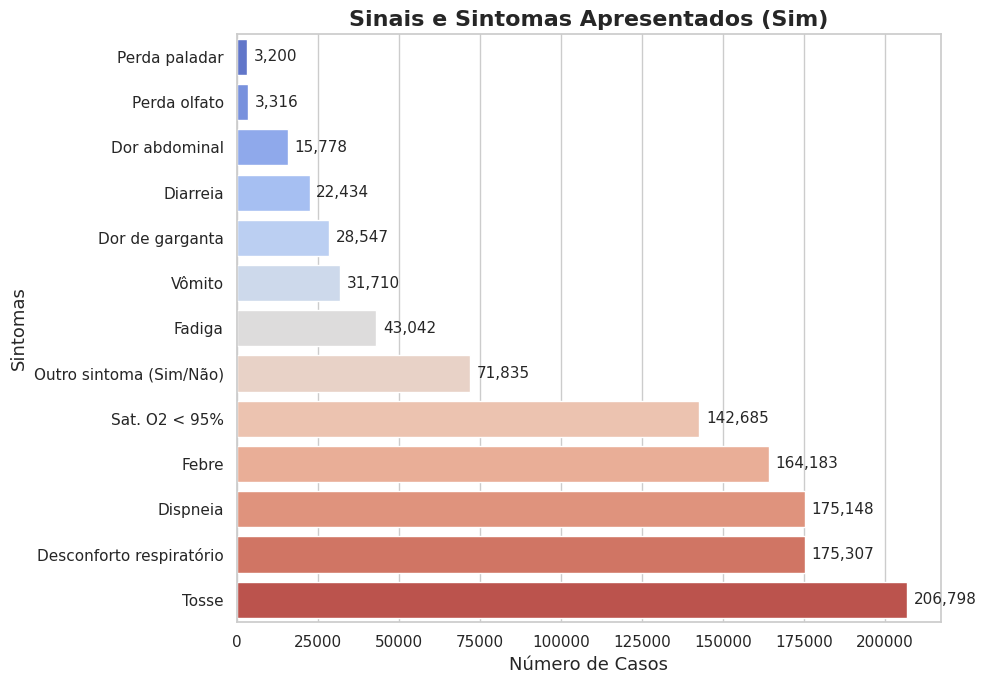

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar quantos pacientes marcaram "1 - Sim" para cada sintoma
sintomas_sim = {col: (df[col] == 1).sum() for col in sintomas}

# Converter para DataFrame ordenado
df_sintomas = pd.DataFrame.from_dict(sintomas_sim, orient='index', columns=['Total'])
df_sintomas['Sintoma'] = df_sintomas.index.map(labels)
df_sintomas = df_sintomas.sort_values(by='Total', ascending=True)

# Plot horizontal
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=df_sintomas,
    y='Sintoma',
    x='Total',
    palette='coolwarm'
)

# Adicionar rótulos
for index, value in enumerate(df_sintomas['Total']):
    plt.text(value + df_sintomas['Total'].max() * 0.01, index, f'{value:,}', va='center', fontsize=11)

plt.title('Sinais e Sintomas Apresentados (Sim)', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Sintomas', fontsize=13)
plt.tight_layout()
plt.show()


# Nuvem de Palavras dos Sintomas Livres (OUTRO_DES)

OUTRO_DES:   Listar outros sinais  e  sintomas apresentados pelo paciente


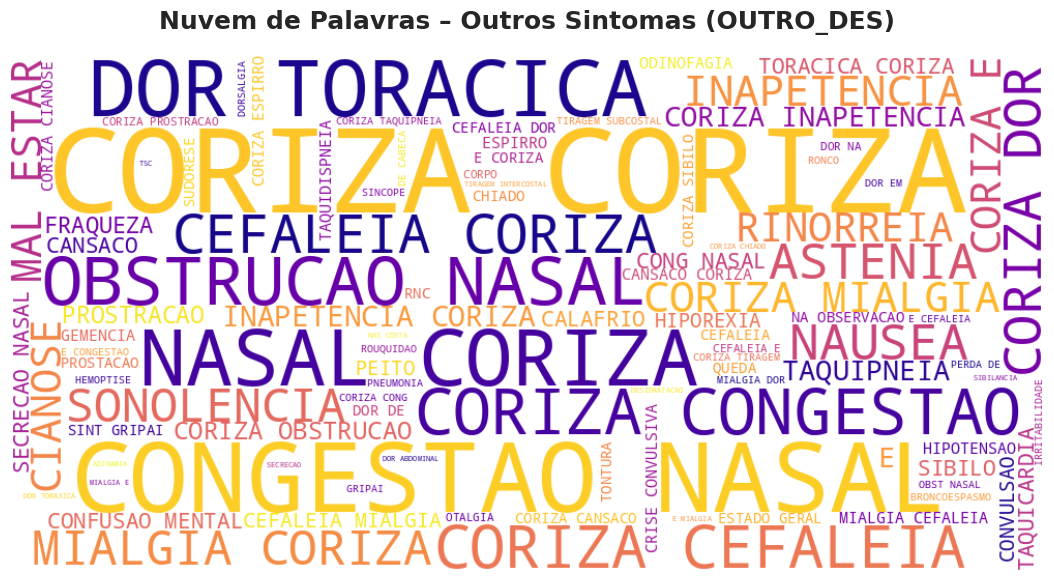

In [36]:
from wordcloud import WordCloud, STOPWORDS

# Remover valores nulos e vazios
texto_outros = df['OUTRO_DES'].dropna()
texto_outros = texto_outros[texto_outros.str.strip() != '']
texto = ' '.join(texto_outros.astype(str).tolist())

# Stopwords básicas
stopwords = set(STOPWORDS)
stopwords.update(['outro', 'sintoma', 'sintomas', 'não', 'apresenta'])

# Criar nuvem de palavras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='plasma',
    max_words=100,
    stopwords=stopwords,
    contour_color='black'
).generate(texto)

# Mostrar nuvem
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Outros Sintomas (OUTRO_DES)', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()


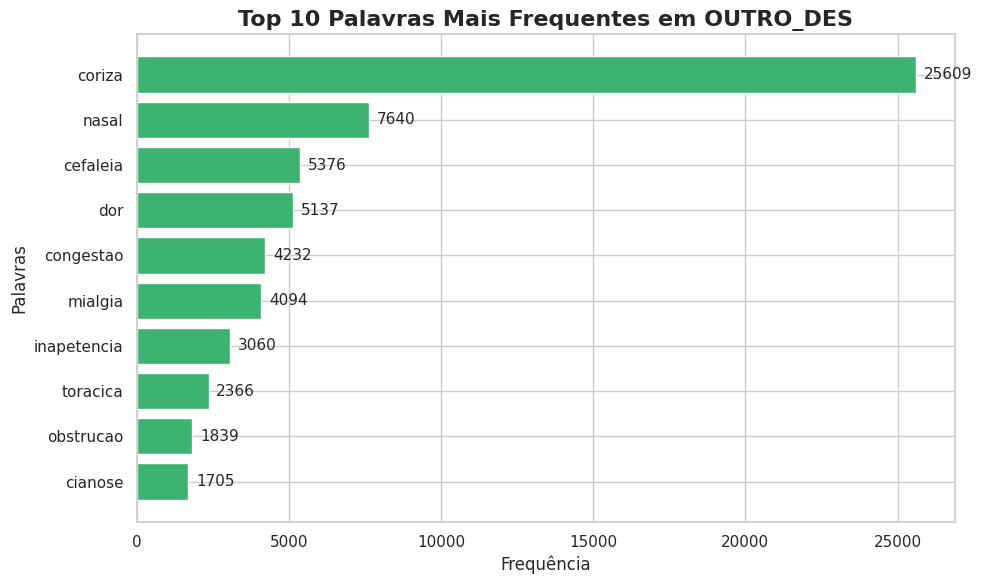

In [48]:
import matplotlib.pyplot as plt
from collections import Counter
import re
from wordcloud import STOPWORDS

# 1. Extrair textos não nulos e não vazios
outro_des_texts = df['OUTRO_DES'].dropna()
outro_des_texts = outro_des_texts[outro_des_texts.str.strip() != '']

# 2. Unir todos os textos em uma string só
texto = ' '.join(outro_des_texts.astype(str).tolist()).lower()

# 3. Limpeza básica: manter só letras e números, substituir outros por espaço
texto = re.sub(r'[^a-záéíóúãõç0-9\s]', ' ', texto)

# 4. Tokenizar (quebrar em palavras)
palavras = texto.split()

# 5. Remover stopwords em português e algumas específicas
stopwords = set(STOPWORDS)
stopwords.update([
    'outro', 'sintoma', 'sintomas', 'nao', 'sem', 'com', 'e', 'a', 'o', 'para', 'em', 'paciente',
    'pacientes', 'relatado', 'relatada', 'presente', 'presença'
])

palavras_filtradas = [p for p in palavras if p not in stopwords and len(p) > 2]

# 6. Contar frequência
freq_palavras = Counter(palavras_filtradas)

# 7. Top 10 palavras mais comuns
top_10 = freq_palavras.most_common(10)

# 8. Preparar para plot
palavras_top10 = [p[0] for p in top_10]
contagens_top10 = [p[1] for p in top_10]

# Plot gráfico
plt.figure(figsize=(10,6))
bars = plt.barh(palavras_top10[::-1], contagens_top10[::-1], color='mediumseagreen')
plt.title('Top 10 Palavras Mais Frequentes em OUTRO_DES', fontsize=16, weight='bold')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

# Adicionar número na frente das barras
for bar in bars:
    largura = bar.get_width()
    plt.text(largura + max(contagens_top10)*0.01, bar.get_y() + bar.get_height()/2, f'{int(largura)}',
             va='center', fontsize=11)

plt.tight_layout()
plt.show()


# Fatores de Risco
Selecionado os fatores de Risco (PUERPERA, CARDIOPATI,HEMATOLOGI, SIND_DOWN, HEPATICA, ASMA , DIABETES , NEUROLOGIC , PNEUMOPATI , IMUNODEPRE, RENAL, OBESIDADE, OUT_MORBI)
Onde:
1-Sim
2-Não
9-Ignorado

* OBES_IMC: Valor do IMC (Índice de Massa Corporal) do paciente calculado pelo profissional de saúde

* MORB_DESC: Listar outro(s) fator(es) de risco do paciente




In [37]:
fatores_binarios = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Nomes legíveis
fatores_labels = {
    'PUERPERA': 'Puérpera',
    'CARDIOPATI': 'Cardiopatia',
    'HEMATOLOGI': 'Doença hematológica',
    'SIND_DOWN': 'Síndrome de Down',
    'HEPATICA': 'Doença hepática',
    'ASMA': 'Asma',
    'DIABETES': 'Diabetes',
    'NEUROLOGIC': 'Doença neurológica',
    'PNEUMOPATI': 'Doença pulmonar crônica',
    'IMUNODEPRE': 'Imunodepressão',
    'RENAL': 'Doença renal crônica',
    'OBESIDADE': 'Obesidade',
    'OUT_MORBI': 'Outro fator de risco (sim/não)'
}


<ipython-input-38-8cb3d9e00694>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_fatores, y='Fator', x='Total', palette='crest')


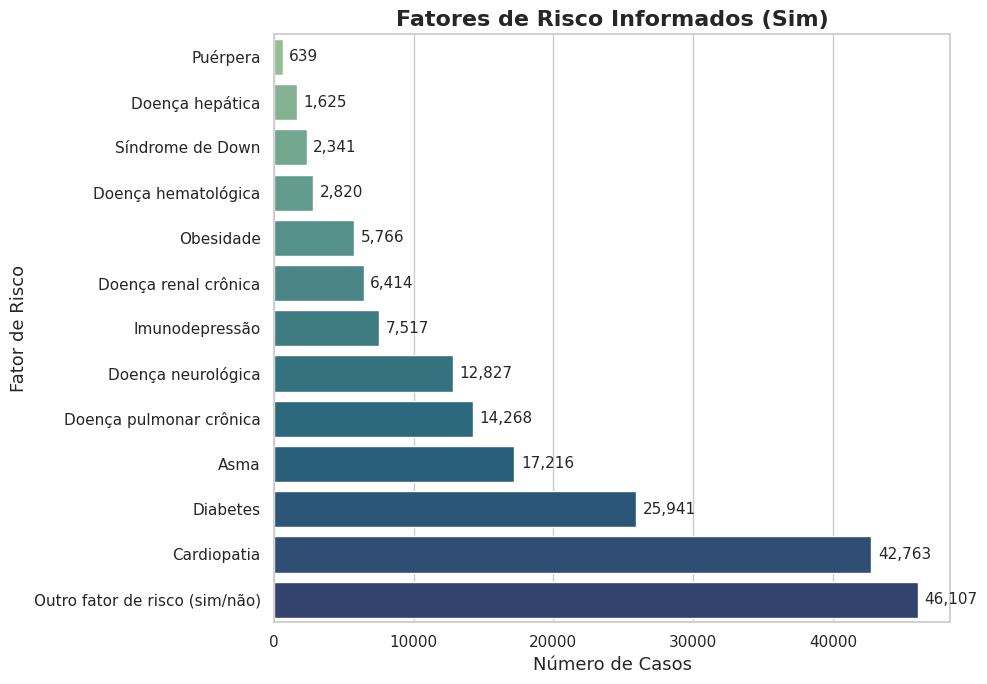

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar "Sim" (1) em cada fator
fatores_sim = {col: (df[col] == 1).sum() for col in fatores_binarios}

# DataFrame ordenado
df_fatores = pd.DataFrame.from_dict(fatores_sim, orient='index', columns=['Total'])
df_fatores['Fator'] = df_fatores.index.map(fatores_labels)
df_fatores = df_fatores.sort_values(by='Total', ascending=True)

# Plot
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
barplot = sns.barplot(data=df_fatores, y='Fator', x='Total', palette='crest')

# Rótulos
for i, v in enumerate(df_fatores['Total']):
    plt.text(v + df_fatores['Total'].max() * 0.01, i, f'{v:,}', va='center', fontsize=11)

plt.title('Fatores de Risco Informados (Sim)', fontsize=16, weight='bold')
plt.xlabel('Número de Casos', fontsize=13)
plt.ylabel('Fator de Risco', fontsize=13)
plt.tight_layout()
plt.show()


Histograma do IMC (OBES_IMC)

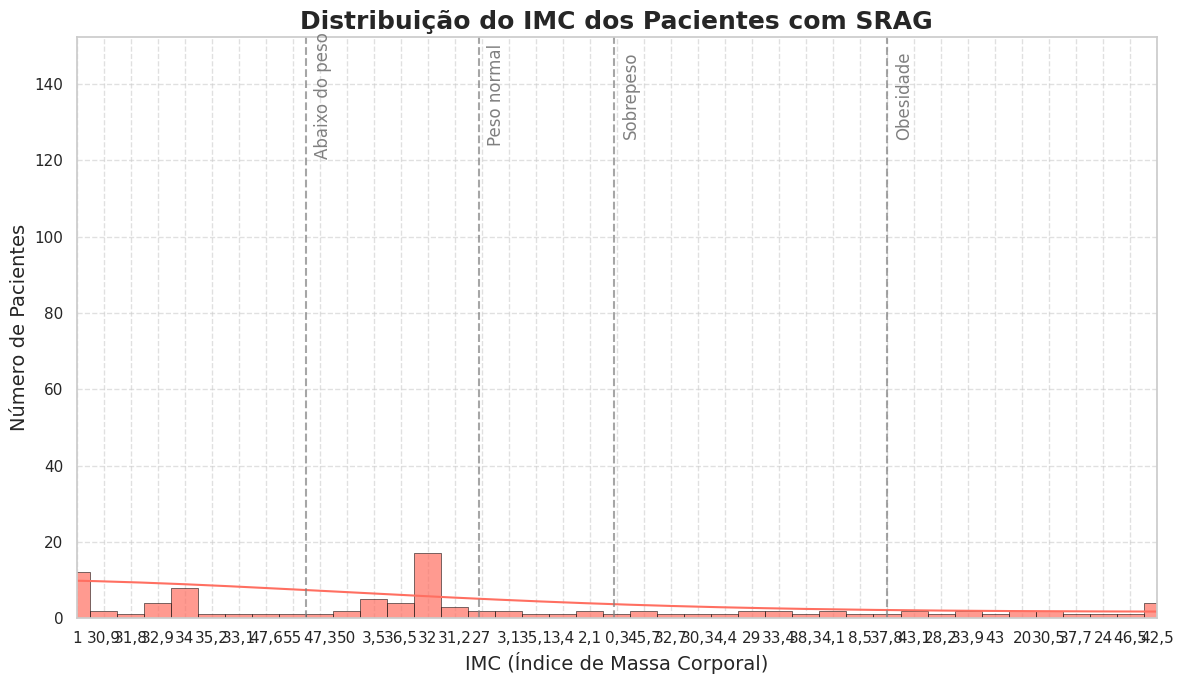

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,7))
sns.set_style("whitegrid")

# Histograma com KDE, cor agradável
sns.histplot(df['OBES_IMC'].dropna(), bins=30, kde=True, color='#FF6F61', edgecolor='black', alpha=0.7)

# Títulos e labels
plt.title('Distribuição do IMC dos Pacientes com SRAG', fontsize=18, weight='bold')
plt.xlabel('IMC (Índice de Massa Corporal)', fontsize=14)
plt.ylabel('Número de Pacientes', fontsize=14)

# Limites do eixo x e linhas de referência para categorias padrão de IMC
plt.xlim(10, 50)
imc_categorias = {
    'Abaixo do peso': 18.5,
    'Peso normal': 24.9,
    'Sobrepeso': 29.9,
    'Obesidade': 40
}
for cat, val in imc_categorias.items():
    plt.axvline(val, color='gray', linestyle='--', alpha=0.7)
    plt.text(val + 0.3, plt.ylim()[1]*0.9, cat, rotation=90, color='gray', fontsize=12, verticalalignment='center')

# Melhor grid e layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


Nuvem de Palavras com MORB_DESC

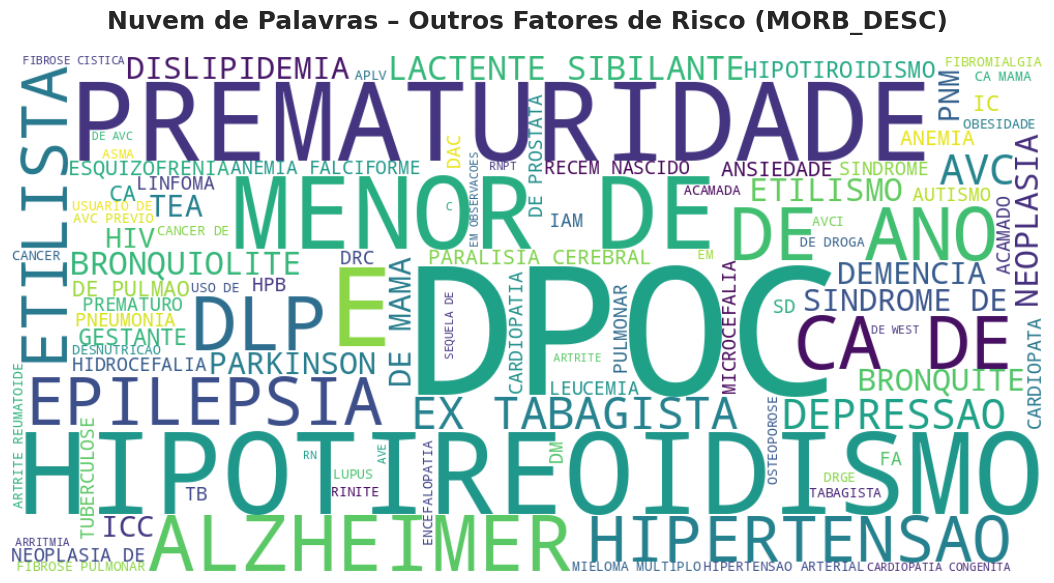

In [41]:
from wordcloud import WordCloud, STOPWORDS

# Texto dos outros fatores de risco
morbi_text = df['MORB_DESC'].dropna()
morbi_text = morbi_text[morbi_text.str.strip() != '']
texto_morbi = ' '.join(morbi_text.astype(str).tolist())

# Stopwords
stopwords = set(STOPWORDS)
stopwords.update(['outro', 'doenca', 'cronica', 'nao', 'apresenta'])

# WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100,
    stopwords=stopwords
).generate(texto_morbi)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras – Outros Fatores de Risco (MORB_DESC)', fontsize=18, weight='bold', pad=20)
plt.tight_layout()
plt.show()


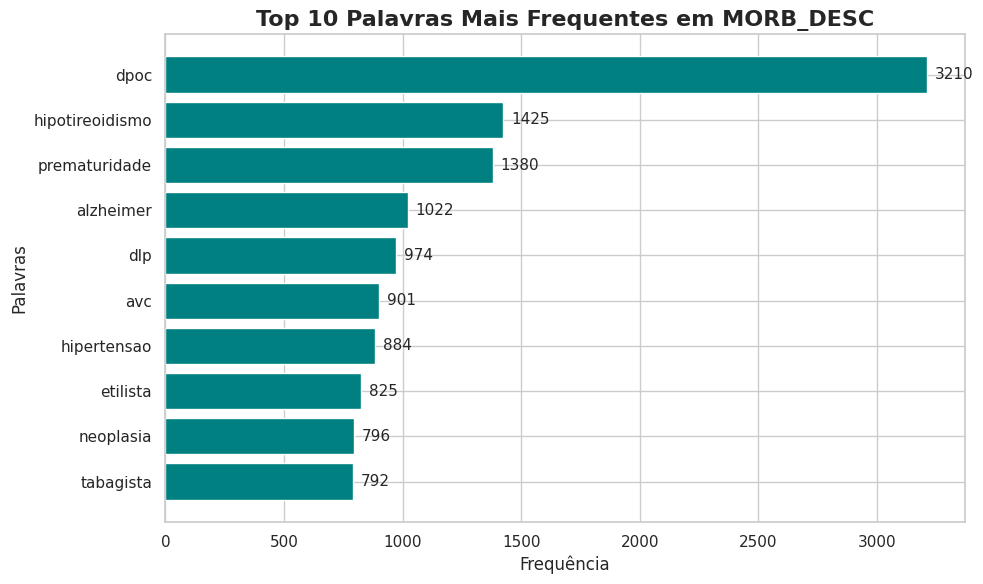

In [46]:
import matplotlib.pyplot as plt
from collections import Counter
import re
from wordcloud import STOPWORDS

# 1. Extrair textos não nulos e não vazios
morbi_texts = df['MORB_DESC'].dropna()
morbi_texts = morbi_texts[morbi_texts.str.strip() != '']

# 2. Unir todos os textos em uma string só
texto = ' '.join(morbi_texts.astype(str).tolist()).lower()

# 3. Limpeza básica: manter só letras e números, substituir outros por espaço
texto = re.sub(r'[^a-záéíóúãõç0-9\s]', ' ', texto)

# 4. Tokenizar (quebrar em palavras)
palavras = texto.split()

# 5. Remover stopwords em português e algumas específicas
stopwords = set(STOPWORDS)
stopwords.update([
    'outro', 'fator', 'de', 'risco', 'doença', 'doenca', 'cronica', 'cronico',
    'nao', 'sem', 'com', 'e', 'a', 'o', 'para', 'em', 'paciente', 'pacientes',
    'comorbidade', 'crônica', 'crônico', 'menor', 'anos'
])

palavras_filtradas = [p for p in palavras if p not in stopwords and len(p) > 2]

# 6. Contar frequência
freq_palavras = Counter(palavras_filtradas)

# 7. Top 10 palavras mais comuns
top_10 = freq_palavras.most_common(10)

# 8. Preparar para plot
palavras_top10 = [p[0] for p in top_10]
contagens_top10 = [p[1] for p in top_10]

# Plot gráfico
plt.figure(figsize=(10,6))
bars = plt.barh(palavras_top10[::-1], contagens_top10[::-1], color='teal')
plt.title('Top 10 Palavras Mais Frequentes em MORB_DESC', fontsize=16, weight='bold')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

# Adicionar número na frente das barras
for bar in bars:
    largura = bar.get_width()
    plt.text(largura + max(contagens_top10)*0.01, bar.get_y() + bar.get_height()/2, f'{int(largura)}',
             va='center', fontsize=11)

plt.tight_layout()
plt.show()

